# Proyecto Final – Sistema de Recomendación para E-commerce

## Análisis Exploratorio de Datos (EDA)

**Equipo:** FinCommerce Analytics  
**Dataset:** Brazilian E-Commerce Public Dataset by Olist  

---

### Objetivo del EDA

Este análisis tiene como objetivo **entender el comportamiento de compra de los usuarios para desarrollar un sistema de recomendación personalizado.** Para ello, se analizará la interacción cliente-producto con el fin de identificar patrones relevantes, evaluar la calidad de los datos y definir las variables necesarias para el modelado.

En particular, se busca:

- Evaluar la frecuencia y recurrencia de compra.
- Detectar patrones relevantes para recomendación.
- Analizar la concentración de ventas (long tail).
- Medir la sparsity de la matriz usuario-producto.
- Identificar posibles problemas de cold start.
- Evaluar la calidad del dataset.

Los *insights* obtenidos permitirán orientar la selección de técnicas de recomendación y mejorar la toma de decisiones del negocio.

Las variables *clave* que se analizarán son:
- Frecuencia de compra
- Ticket promedio
- Productos más vendidos
- Distribución por categorías
- Comportamiento temporal

---

In [6]:
# =================================
# PASO 1: IMPORTACIÓN DE LIBRERÍAS
# =================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

pd.set_option("display.max_columns", None)

---

In [7]:
# =======================================
# PASO 2: CARGA DE DATOS (vía kagglehub)
# =======================================

# Se utiliza kagglehub para descargar el dataset directamente desde Kaggle,
# asegurando acceso a los datos sin necesidad de carga manual.

import kagglehub
import os

path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Dataset descargado en:", path)
print("Archivos:", os.listdir(path))

customers   = pd.read_csv(os.path.join(path, "olist_customers_dataset.csv"))
orders      = pd.read_csv(os.path.join(path, "olist_orders_dataset.csv"))
order_items = pd.read_csv(os.path.join(path, "olist_order_items_dataset.csv"))
products    = pd.read_csv(os.path.join(path, "olist_products_dataset.csv"))
payments    = pd.read_csv(os.path.join(path, "olist_order_payments_dataset.csv"))
reviews     = pd.read_csv(os.path.join(path, "olist_order_reviews_dataset.csv"))
sellers     = pd.read_csv(os.path.join(path, "olist_sellers_dataset.csv"))
geolocation = pd.read_csv(os.path.join(path, "olist_geolocation_dataset.csv"))
translation = pd.read_csv(os.path.join(path, "product_category_name_translation.csv"))

Dataset descargado en: C:\Users\vanin\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2
Archivos: ['olist_customers_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_orders_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_products_dataset.csv', 'olist_sellers_dataset.csv', 'product_category_name_translation.csv']


In [9]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "payments": payments,
    "reviews": reviews
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

customers: (99441, 5)
orders: (99441, 8)
order_items: (112650, 7)
products: (32951, 9)
payments: (103886, 5)
reviews: (99224, 7)


---

In [11]:
# =======================================
# PASO 3: INFORMACIÓN GENERAL DE DATASETS
# =======================================

for name, df in datasets.items():
    print("=" * 70)
    print(f"DATASET: {name.upper()}")
    print("=" * 70)
    df.info()
    print("\n")

DATASET: CUSTOMERS
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


DATASET: ORDERS
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4  

###  *Interpretación:*

La inspección inicial de los datasets permite comprender la estructura general de la información disponible.

Se observa que:

- Las variables categóricas se encuentran almacenadas como tipo `object`, incluyendo identificadores clave como `customer_id`, `order_id` y `product_id`.
- Las variables numéricas presentan formatos adecuados para su análisis.
- Las variables de fecha están almacenadas como texto y deberán ser convertidas a formato `datetime`.

Desde la perspectiva del sistema de recomendación, esta estructura permite:

- vincular clientes, órdenes y productos para construir la interacción usuario-producto;
- analizar el comportamiento de compra a nivel individual;
- generar una matriz usuario-producto, considerando la posible dispersión (sparsity) de los datos.

Todo lo observado muestra la necesidad de realizar procesos de integración, agregación y transformación de datos, lo que será abordado en la etapa de ETL.

---

### A continuación, se evalúa la *calidad* de los datasets utilizados, identificando:

- valores faltantes
- duplicados
- inconsistencias
- posibles problemas estructurales

Este análisis es clave para garantizar la confiabilidad de los resultados y definir las transformaciones necesarias en la etapa de ETL.

In [14]:
# ===============================================================
# PASO 4: ANÁLISIS DE LA CALIDAD DE LOS DATOS 
# a) VALORES FALTANTES
# ===============================================================

def missing_values(df):
    missing = df.isnull().mean() * 100
    missing = missing[missing > 0].sort_values(ascending=False)
    return missing

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    display(missing_values(df))


CUSTOMERS


Series([], dtype: float64)


ORDERS


order_delivered_customer_date    2.981668
order_delivered_carrier_date     1.793023
order_approved_at                0.160899
dtype: float64


ORDER_ITEMS


...

product_category_name         1.851234
product_name_lenght           1.851234
product_description_lenght    1.851234
product_photos_qty            1.851234
product_weight_g              0.006070
product_length_cm             0.006070
product_height_cm             0.006070
product_width_cm              0.006070
dtype: float64


PAYMENTS


Series([], dtype: float64)


REVIEWS


review_comment_title      88.341530
review_comment_message    58.702532
dtype: float64

In [15]:
# ===============================================================
# PASO 4: ANÁLISIS DE LA CALIDAD DE LOS DATOS 
# b) VALORES DUPLICADOS
# ===============================================================

for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    print(f"{name}: {duplicates} duplicados")

customers: 0 duplicados
orders: 0 duplicados
order_items: 0 duplicados
products: 0 duplicados
payments: 0 duplicados
reviews: 0 duplicados


###  *Interpretación:*

No se observan duplicados significativos en los datasets principales. Esto es importante para garantizar la consistencia del análisis, especialmente en tablas transaccionales como orders y order_items, donde la duplicación podría generar distorsiones en el comportamiento de compra.

En caso de detectarse inconsistencias en etapas posteriores, serán tratadas durante el proceso de ETL.

---

In [23]:
# PASO 5: INTEGRACIÓN DE DATOS Y ANÁLISIS DEL COMPORTAMIENTO DE CLIENTES
df = orders.merge(order_items, on="order_id", how="inner") \
           .merge(products, on="product_id", how="left") \
           .merge(customers, on="customer_id", how="left") \
           .merge(payments, on="order_id", how="left")

In [24]:
df.shape

(117604, 30)

In [25]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,credit_card,3.0,179.12


### Integración de tablas

La integración de las distintas tablas permite construir una vista unificada del proceso de compra, combinando información de clientes, órdenes, productos y transacciones.

Esta unión es fundamental para el análisis, ya que:

- Permite vincular entidades clave como clientes (`customer_id`), órdenes (`order_id`) y productos (`product_id`).
- Define la granularidad del análisis a nivel de ítem de orden.
- Habilita la construcción de variables de comportamiento (frecuencia, recurrencia, co-compra).

Desde la perspectiva del sistema de recomendación, esta estructura integrada es esencial para:

- Analizar patrones de compra.
- Construir la matriz usuario-producto.
- Detectar relaciones entre productos (co-compra).

Estas transformaciones constituyen la base para las etapas posteriores de ETL y modelado.

_________________________________________________________________________________________________________________________________

### A continuación, se analiza *cómo interactúan los clientes con el sistema*, evaluando su frecuencia de compra y nivel de actividad. Este análisis es clave para entender la viabilidad de un sistema de recomendación basado en historial.

In [ ]:
# PASO 5: ANÁLISIS DEL CLIENTE: Nº DE ÓRDENES POR CLIENTE Y ESTADÍSTICA DESCRIPTIVA

orders_per_customer = df.groupby("customer_unique_id")["order_id"].nunique()
orders_per_customer.describe()

count    95420.000000
mean         1.034018
std          0.211234
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         16.000000
Name: order_id, dtype: float64

In [27]:
orders_per_customer.value_counts().head(10)

order_id
1     92507
2      2673
3       192
4        29
5         9
6         5
7         3
9         1
16        1
Name: count, dtype: int64

*Interpretación:* 
Nos preguntamos... ¿Cómo es la distribución en general? ¿Hay clientes que compran más frecuentemente? ¿Cuántos clientes hay en cada grupo?

Se observa que la gran mayoría de los clientes realiza una única compra, lo que limita la posibilidad de aplicar modelos basados en historial.

Este comportamiento impacta directamente en:
- la capacidad de personalización,
- la robustez del filtrado colaborativo.

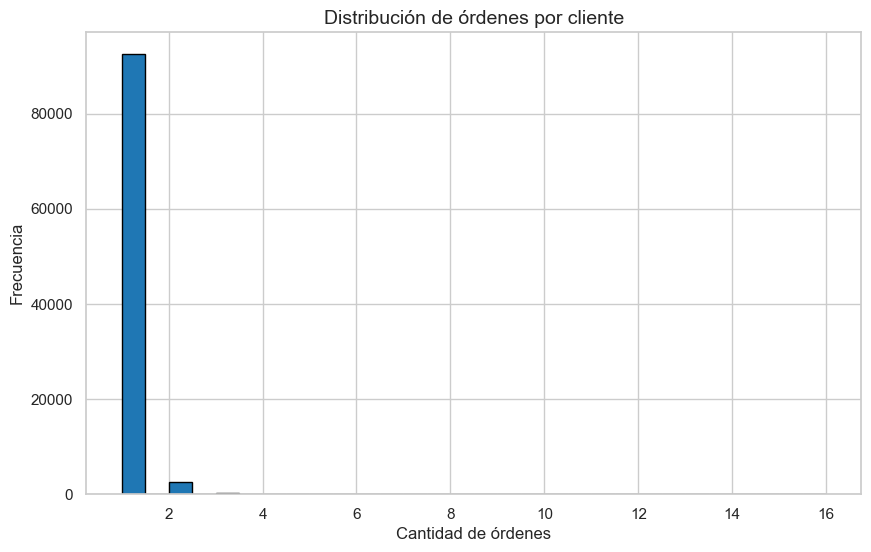

In [28]:
# PASO 6: VISUALIZACIÓN MEDIANTE HISTOGRAMA DE ÓRDENES POR CLIENTE

plt.figure(figsize=(10, 6))

orders_per_customer.hist(
    bins=30,
    color="#1f77b4",
    edgecolor="black"
)

plt.title("Distribución de órdenes por cliente", fontsize=14)
plt.xlabel("Cantidad de órdenes")
plt.ylabel("Frecuencia")
plt.show()

<Axes: >

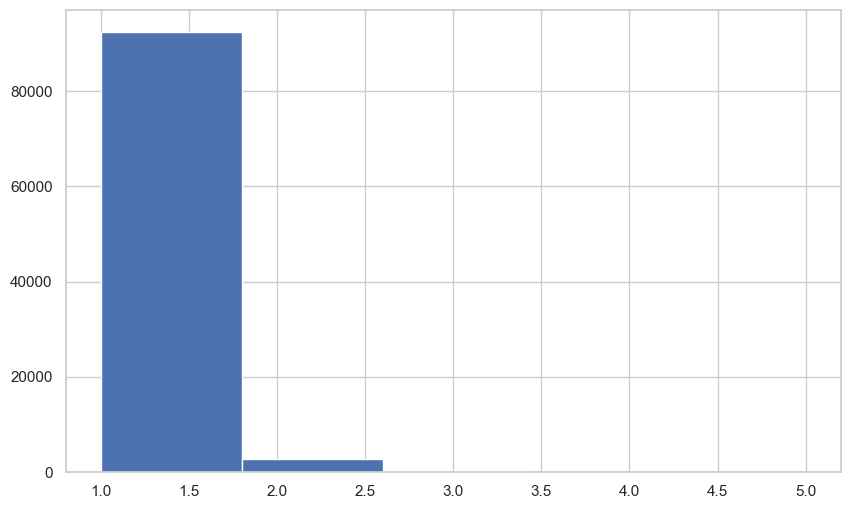

In [30]:
# Recorte de la distribución para visualizar mejor la concentración de valores bajos.
orders_per_customer.clip(upper=5).hist(bins=5)

**Consideración importante sobre la identificación de clientes**

En este dataset, `customer_id` no representa necesariamente un cliente real único a lo largo del tiempo, sino un identificador asociado a cada pedido.

Por este motivo, para analizar la recurrencia de compra se utiliza `customer_unique_id`, que permite seguir al mismo cliente a través de múltiples órdenes.

Esta decisión es importante para evitar interpretaciones incorrectas y realizar un análisis consistente del comportamiento de compra.

*Interpretación de la frecuencia de compra por cliente:*

Los resultados muestran una fuerte concentración en clientes de compra única, mientras que solo una fracción reducida presenta múltiples órdenes. Esto evidencia una matriz usuario-producto altamente dispersa (**sparsity**) y un problema relevante de **cold start**, ya que gran parte de los usuarios cuenta con poco historial para inferir preferencias.

Desde la perspectiva del sistema de recomendación, este comportamiento limita la efectividad de enfoques basados exclusivamente en filtrado colaborativo y refuerza la necesidad de incorporar estrategias complementarias, como recomendaciones basadas en popularidad, contenido o modelos híbridos.

______________________________________________________________________________

###  Análisis de productos y categorías

En esta sección se estudia la distribución de productos y categorías dentro del marketplace, con el objetivo de identificar patrones de concentración de ventas y evaluar la presencia de long tail.

Este análisis es clave para entender si el sistema tenderá a recomendar siempre los mismos productos o si existe espacio para estrategias de diversificación.

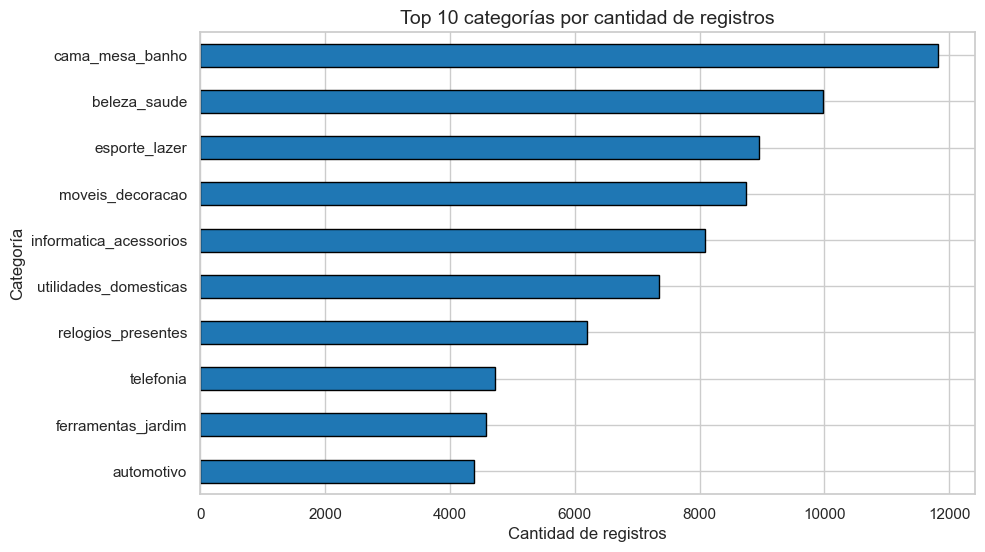

In [31]:
# PASO 7: ANÁLISIS DE CATEGORÍAS: TOP 10 CATEGORÍAS POR CANTIDAD DE REGISTROS

top_categories = (
    df["product_category_name"]
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))
top_categories.plot(
    kind="barh",
    color="#1f77b4",
    edgecolor="black"
)

plt.title("Top 10 categorías por cantidad de registros", fontsize=14)
plt.xlabel("Cantidad de registros")
plt.ylabel("Categoría")
plt.show()

*Interpretación:*

Se observa que una parte reducida de categorías concentra gran parte de la actividad del marketplace. Este patrón sugiere una distribución desigual de la demanda y anticipa la presencia de un fenómeno de **long tail**, donde pocas categorías o productos explican la mayor parte de las interacciones, mientras que una gran cantidad presenta baja frecuencia.

Desde la perspectiva del sistema de recomendación, esto implica un riesgo de sesgo hacia productos populares si no se incorporan mecanismos de diversidad o exploración.

Este comportamiento sugiere que un sistema basado únicamente en popularidad tendería a reforzar el sesgo hacia productos más vendidos, reduciendo la diversidad de recomendaciones.

In [32]:
product_counts = df["product_id"].value_counts()

In [33]:
total_sales = product_counts.sum()

top_20_pct_products = int(len(product_counts) * 0.2)

top_sales = product_counts.head(top_20_pct_products).sum()

percentage = (top_sales / total_sales) * 100

print(f"El 20% de los productos genera el {percentage:.2f}% de las compras")

El 20% de los productos genera el 67.39% de las compras


*Interpretación del fenómeno **Long Tail***

El análisis muestra que aproximadamente el 20% de los productos concentra una proporción significativa de las compras totales.

Este resultado confirma una distribución altamente desigual en la demanda, característica de plataformas de e-commerce.

Desde la perspectiva del sistema de recomendación:

- Un modelo basado únicamente en popularidad tenderá a sobre-recomendar este subconjunto reducido de productos.
- Existe un riesgo de invisibilizar gran parte del catálogo.
- Se vuelve necesario incorporar estrategias que promuevan diversidad y exploración.

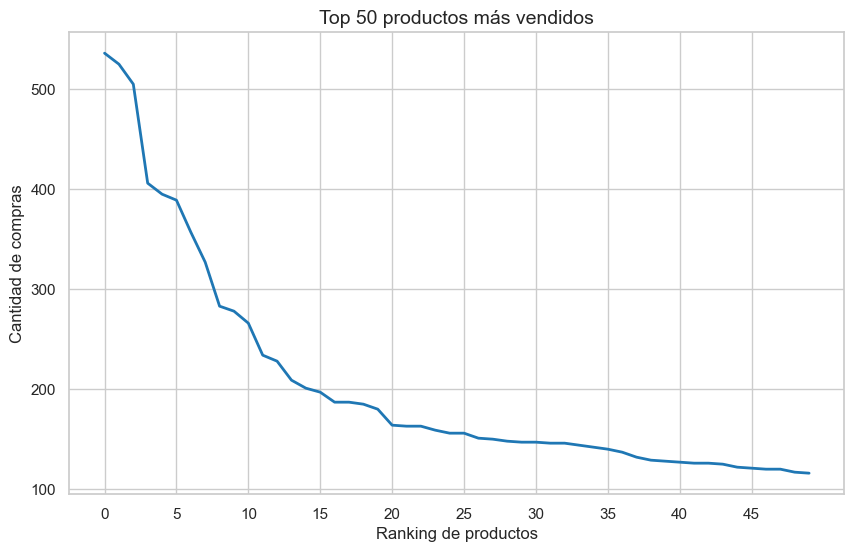

In [40]:
# PASO 8: VISUALIZACIÓN DE LOS PRODUCTOS MÁS VENDIDOS - TOP 50

plt.figure(figsize=(10, 6))

top_products = product_counts.head(50).reset_index(drop=True)

top_products.plot(
    color="#1f77b4",
    linewidth=2
)

plt.title("Top 50 productos más vendidos", fontsize=14)
plt.xlabel("Ranking de productos")
plt.ylabel("Cantidad de compras")

plt.xticks(range(0, 50, 5))  # cada 5 posiciones

plt.show()

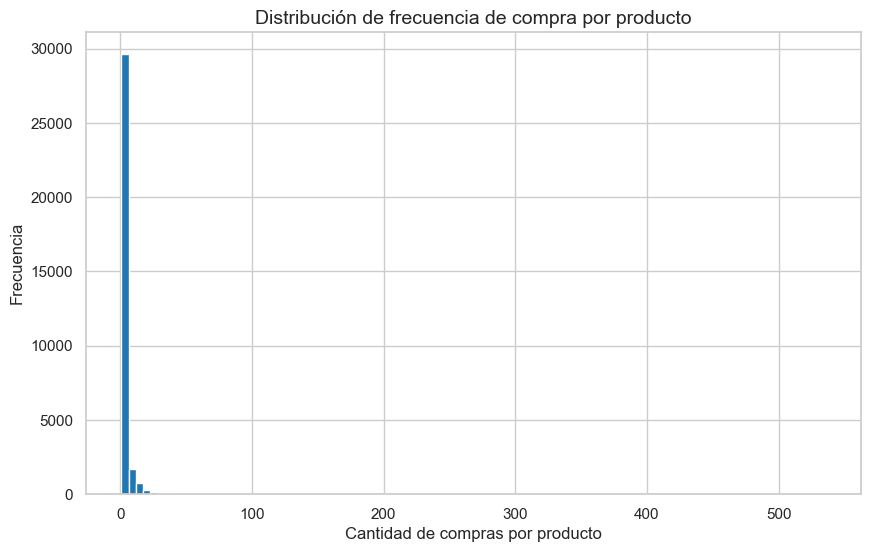

In [42]:
# PASO 9: VISUALIZACIÓN DE LA DISTRIBUCIÓN DE COMPRAS POR PRODUCTO

plt.figure(figsize=(10, 6))

product_counts.plot(
    kind="hist",
    bins=100,
    color="#1f77b4"
)

plt.title("Distribución de frecuencia de compra por producto", fontsize=14)
plt.xlabel("Cantidad de compras por producto")
plt.ylabel("Frecuencia")

plt.show()

*Interpretación adicional de **Long-tail**:*

El análisis de la frecuencia de compra por producto evidencia una distribución extremadamente desigual. Se observa:

- Un número reducido de productos concentra una gran cantidad de compras.
- Una gran proporción de productos presenta muy pocas interacciones.

Este comportamiento corresponde a un fenómeno de **long tail**, característico de plataformas de e-commerce.

Desde la perspectiva del *sistema de recomendación:*

- Existe un riesgo de sobre-representar productos populares si no se controlan los sesgos.
- Se vuelve relevante incorporar mecanismos de diversidad en las recomendaciones.
- La gran cantidad de productos con baja interacción puede dificultar la generalización del modelo.

Este patrón refuerza la necesidad de considerar estrategias híbridas que combinen popularidad, contenido y comportamiento del usuario.

______________________________________________________________________________

###  Análisis de *Sparsity* de la matriz usuario-producto
En sistemas de recomendación, la sparsity mide qué tan incompleta es la matriz usuario-producto. Con ello, una matriz muy dispersa implica que la mayoría de las posibles interacciones no están observadas, lo que representa un desafío para modelos basados en comportamiento.

In [20]:
n_users = df["customer_unique_id"].nunique()
n_products = df["product_id"].nunique()

n_interactions = df[["customer_unique_id", "product_id"]].drop_duplicates().shape[0]

density = (n_interactions / (n_users * n_products)) * 100

print(f"Usuarios: {n_users}")
print(f"Productos: {n_products}")
print(f"Interacciones únicas: {n_interactions}")
print(f"Densidad: {density:.4f}%")

Usuarios: 95420
Productos: 32951
Interacciones únicas: 101987
Densidad: 0.0032%


*Interpretación de sparsity*
Una densidad del 0.0032% que, en este caso, es extremadamente baja, indica una matriz extremadamente dispersa, donde menos del 1% de las posibles interacciones están observadas Este nivel de dispersión es característico de datasets de e-commerce a gran escala y representa un desafío significativo para el modelado.

Desde la perspectiva del sistema de recomendación:

- La baja densidad limita la capacidad de los modelos de filtrado colaborativo para identificar patrones robustos.
- La mayoría de los usuarios tiene muy pocas interacciones, lo que agrava el problema de cold start.
- La gran cantidad de productos con baja frecuencia dificulta la generalización del modelo.

Este nivel de sparsity es típico en sistemas de recomendación reales y representa un desafío central para modelos de filtrado colaborativo.

En este contexto, resulta necesario considerar enfoques híbridos que combinen:

- popularidad global,
- información de contenido,
- y comportamiento agregado de usuarios.

_______________________________________________________________________________

## 🛒 Análisis de co-compra (productos complementarios)

En esta sección se analizan los productos que se compran juntos dentro de una misma orden.

El objetivo es identificar patrones de complementariedad que puedan ser utilizados en el sistema de recomendación para estrategias de cross-selling.

In [25]:
basket = df.groupby("order_id")["product_id"].apply(list)

In [26]:
basket = basket[basket.apply(len) > 1]

### Consideración metodológica

Para el análisis de co-compra, se consideran únicamente órdenes que contienen más de un producto.

Además, se eliminan duplicados a nivel de análisis (no del dataset original) para evitar combinaciones irrelevantes de un producto consigo mismo.

Estas transformaciones son temporales y no modifican los datos originales.

In [27]:
from itertools import combinations
from collections import Counter

pair_counter = Counter()

for products in basket:
    unique_products = list(set(products))  # elimina repetidos SOLO para análisis
    pairs = combinations(unique_products, 2)
    pair_counter.update(pairs)

In [28]:
top_pairs = pair_counter.most_common(10)

top_pairs

[(('36f60d45225e60c7da4558b070ce4b60', 'e53e557d5a159f5aa2c5e995dfdf244b'),
  34),
 (('f4f67ccaece962d013a4e1d7dc3a61f7', '4fcb3d9a5f4871e8362dfedbdb02b064'),
  17),
 (('99a4788cb24856965c36a24e339b6058', '35afc973633aaeb6b877ff57b2793310'),
  15),
 (('35afc973633aaeb6b877ff57b2793310', '99a4788cb24856965c36a24e339b6058'),
  14),
 (('36f60d45225e60c7da4558b070ce4b60', '3f14d740544f37ece8a9e7bc8349797e'),
  12),
 (('422879e10f46682990de24d770e7f83d', '389d119b48cf3043d311335e499d9c6b'),
  11),
 (('53759a2ecddad2bb87a079a1f1519f73', '389d119b48cf3043d311335e499d9c6b'), 9),
 (('368c6c730842d78016ad823897a372db', '53759a2ecddad2bb87a079a1f1519f73'), 8),
 (('dbb67791e405873b259e4656bf971246', '18486698933fbb64af6c0a255f7dd64c'), 7),
 (('422879e10f46682990de24d770e7f83d', '53759a2ecddad2bb87a079a1f1519f73'), 7)]

In [29]:
product_to_category = df.set_index("product_id")["product_category_name"].to_dict()

In [30]:
top_pairs_categories = [
    (
        (product_to_category.get(p1), product_to_category.get(p2)),
        count
    )
    for (p1, p2), count in top_pairs
]

top_pairs_categories

[(('informatica_acessorios', 'informatica_acessorios'), 34),
 (('automotivo', 'automotivo'), 17),
 (('cama_mesa_banho', 'casa_conforto'), 15),
 (('casa_conforto', 'cama_mesa_banho'), 14),
 (('informatica_acessorios', 'informatica_acessorios'), 12),
 (('ferramentas_jardim', 'ferramentas_jardim'), 11),
 (('ferramentas_jardim', 'ferramentas_jardim'), 9),
 (('ferramentas_jardim', 'ferramentas_jardim'), 8),
 (('informatica_acessorios', 'informatica_acessorios'), 7),
 (('ferramentas_jardim', 'ferramentas_jardim'), 7)]

### Interpretación inicial de co-compra

El análisis de co-compra muestra que muchos productos adquiridos en una misma orden pertenecen a la misma categoría.

Esto indica que los usuarios suelen comprar múltiples productos relacionados dentro de un mismo tipo, lo que sugiere patrones de compra orientados a necesidades específicas (por ejemplo, productos del hogar o accesorios tecnológicos).

Sin embargo, para el sistema de recomendación resulta especialmente relevante identificar combinaciones entre categorías distintas, ya que estas reflejan relaciones de complementariedad más amplias.

In [31]:
top_pairs_diff_categories = [
    (pair, count)
    for pair, count in top_pairs_categories
    if pair[0] != pair[1]
]

top_pairs_diff_categories

[(('cama_mesa_banho', 'casa_conforto'), 15),
 (('casa_conforto', 'cama_mesa_banho'), 14)]

### Complementariedad entre categorías

Al analizar combinaciones entre categorías distintas, se identifican patrones claros de compra conjunta que reflejan relaciones de complementariedad.

Por ejemplo, la combinación entre categorías del hogar sugiere que los usuarios tienden a adquirir productos relacionados dentro de un mismo contexto de uso.

Desde la perspectiva del sistema de recomendación:

- Permite generar recomendaciones más relevantes basadas en contexto de compra.
- Habilita estrategias efectivas de cross-selling.
- Contribuye a incrementar el ticket promedio mediante sugerencias complementarias.

Este tipo de relaciones resulta especialmente valioso para sistemas híbridos que combinan comportamiento histórico con reglas de asociación.

______________________________________________________________________________

## Conclusiones del análisis exploratorio

El análisis exploratorio permitió identificar patrones clave en el comportamiento de usuarios y productos dentro del marketplace.

### Principales hallazgos

- La mayoría de los usuarios realiza una única compra, lo que evidencia un problema de **baja recurrencia** y presencia de **cold start**.
- La matriz usuario-producto presenta una densidad extremadamente baja (alta **sparsity**), lo que dificulta la aplicación de modelos de filtrado colaborativo puro.
- Se confirma un fenómeno de **long tail**, donde un pequeño porcentaje de productos concentra la mayor parte de las compras.
- Existen patrones de **co-compra** tanto dentro de una misma categoría como entre categorías distintas, lo que evidencia relaciones de complementariedad.

### Implicancias para el sistema de recomendación

A partir de estos hallazgos, se concluye que:

- No es suficiente utilizar únicamente modelos basados en popularidad o filtrado colaborativo.
- Se requiere un enfoque **híbrido**, que combine:
  - popularidad de productos,
  - información de contenido (categorías),
  - comportamiento de compra.
- La incorporación de reglas de asociación permitirá mejorar la relevancia de las recomendaciones mediante estrategias de cross-selling.

Este análisis establece las bases para el desarrollo del sistema de recomendación en las siguientes etapas del proyecto.